## 1. Project Framing

##### Run notebook
1. Restart kernel - run all cells
2. Expected runtime - 2 to 4 minutes, depends on Google Trends API response time
3. Requirements - Internet connection for Google Trends retrieval & Python packages such as 'pytrends', 'pandas', 'numpy', 'scikit-learn' & 'matplotlib'
4. Final outputs includes - Model evaluation metrics (ROC-AUC, PR-AUC & F1 score), Baseline comparison, Ranked Top-K emerging keywords table & Diagnostic plots of keyword interest and emergence probability

### 1.2 Project Summary

Thai entertainment production business GMMTV is well-known for creating digital content and television shows with a sizable global fan following. Due to new releases, announcements, and fan interaction, online attention to artists, shows, and related subjects frequently varies quickly.

Using Google Trends search interest as a stand-in for public attention, this notebook creates a **predictive modeling pipeline to detect short-term trend emergence** in GMMTV-related keywords.

Instead of a one-day spike, trend emergence is characterized by a **sustained boost in search interest over the next three days relative to its previous baseline**. This aids in identifying early indicators of growing interest.

We utilize Google Trends because it offers a **platform-independent measure of worldwide search interest** that enables us to track attention dynamics even in situations when direct access to social media APIs is not possible.

The model produces:
- A **probability of emergence** for every term
- A collection of emerging phrases placed in the top K
- Diagnostic plots and evaluation metrics to gauge the quality of predictions

These results show how search interest signals can be utilized to predict new trends in themes linked to entertainment.

## 2. Data Collection - Google Trends

In [1]:
import pandas as pd
import numpy as np
from pytrends.request import TrendReq

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression

#keywords are the "entities" we track for emergence - GMMTV, their artists & series
#google trends is used - proxy for public attention 
KEYWORDS = ["PondPhuwin", "NamtanFilm", "Me and Thee", "Girl Rules", "GMMTV"]

#daily data works best with a longer window: ~90 days
TIMEFRAME = "today 12-m"  
#worldwide; set "TH" if you want Thailand-only
GEO = ""      

#key modelling choices
#how far ahead we predict "emergence"
HORIZON_DAYS = 3
#baseline window used to compute deviation + momentum features 
ROLLING_WINDOW = 7       

### 2.1 Data Collection Output (Raw Data Preview)

In [2]:
#pull daily Google Trends interest for a single keyword
def fetch_single(keyword, timeframe = "today 12-m", geo = "", max_retries = 5):
    #ensures timestamps align to Singapore time
    pytrends = TrendReq(hl = "en-US", tz = 480)

    #use retry + backoff to reduce rate-limit failures and improve reproducibility
    for attempt in range(max_retries):
        try:
            pytrends.build_payload([keyword], timeframe = timeframe, geo = geo)
            df = pytrends.interest_over_time()
            #drop partial data points returned by Google Trends
            if "isPartial" in df.columns:
                df = df.drop(columns = ["isPartial"])
                
            df = df.rename(columns = {keyword: "interest"})
            df.index = pd.to_datetime(df.index)
            df["keyword"] = keyword
            return df.reset_index().rename(columns = {"index": "date"})

        except Exception as e:
            #simple backoff
            wait = 5 * (attempt + 1)
            print(f"{keyword}: failed ({e}). Retry in {wait}s...")
            time.sleep(wait)

    raise RuntimeError(f"Failed for {keyword}")

df_list = []
for k in KEYWORDS:
    df_list.append(fetch_single(k, TIMEFRAME, GEO))
df_long = pd.concat(df_list, ignore_index = True)

df_long.head()

C:\Users\charl\anaconda3\envs\fyp-trend\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
C:\Users\charl\anaconda3\envs\fyp-trend\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
C:\Users\charl\anaconda3\envs\fyp-trend\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To 

,date,interest,keyword
0,2025-03-02,22,PondPhuwin
1,2025-03-09,25,PondPhuwin
2,2025-03-16,26,PondPhuwin
3,2025-03-23,30,PondPhuwin
4,2025-03-30,29,PondPhuwin


### 2.2 Reproducibility Setup

In [3]:
#setting seeds ensures consistent results across runs
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Random seed set to:", SEED)

#print key library versions for reproducibility
import sklearn 
import pandas as pd

print("scikit-learn version:", sklearn.__version__)
print("pandas version:", pd.__version__)

Random seed set to: 42
scikit-learn version: 1.7.2
pandas version: 2.3.3


## 3. Data Quality/Checks

In [4]:
#sanity check - confirm data range, number of keywords and missingness
#helps to justify data quality and limitations
print("Keywords:", df_long["keyword"].nunique())
print("Date range:", df_long["date"].min(), "to", df_long["date"].max())
print("Rows:", len(df_long))

missing_by_keyword = df_long.groupby("keyword")["interest"].apply(lambda s: s.isna().mean()).sort_values(ascending = False)
missing_by_keyword.head(10)

Keywords: 5
Date range: 2025-03-02 00:00:00 to 2026-03-01 00:00:00
Rows: 265


keyword
GMMTV          0.0
Girl Rules     0.0
Me and Thee    0.0
NamtanFilm     0.0
PondPhuwin     0.0
Name: interest, dtype: float64

## 4. Feature Engineering

In [5]:
df_long = df_long.sort_values(["keyword", "date"]).reset_index(drop = True)

def add_time_features(g, w = 7):
    g = g.copy()
    #baseline behaviour (rolling mean & std) to represent "normal" interest level per keyword
    g["roll_mean"] = g["interest"].rolling(w, min_periods = w).mean()
    g["roll_std"] = g["interest"].rolling(w, min_periods = w).std(ddof = 0)

    #standarised deviation from baseline (z-score) - early anomaly signal
    g["z"] = (g["interest"] - g["roll_mean"]) / g["roll_std"].replace(0, np.nan)

    #short-term acceleration signals (day-to-day and 3-day change)
    g["pct_change_1"] = g["interest"].pct_change(1)
    g["pct_change_3"] = g["interest"].pct_change(3)

    g["momentum_1"] = g["interest"].diff(1)
    g["momentum_3"] = g["interest"].diff(3)

    #volatility - noise/instability indicator (helps separate spikes from sustained growth)
    g["volatility_7"] = g["interest"].rolling(7, min_periods = 7).std(ddof = 0)

    #keep NaNs for early rows (insufficient history) & handle missing values later in modelling
    return g

feat = df_long.groupby("keyword", group_keys = False).apply(add_time_features, w = ROLLING_WINDOW)
feat.tail()

C:\Users\charl\AppData\Local\Temp\ipykernel_14952\3176467988.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feat = df_long.groupby("keyword", group_keys = False).apply(add_time_features, w = ROLLING_WINDOW)


,date,interest,keyword,roll_mean,roll_std,z,pct_change_1,pct_change_3,momentum_1,momentum_3,volatility_7
260,2026-02-01,69,PondPhuwin,79.285714,10.109603,-1.017420,-0.092105,-0.148148,-7.0,-12.0,10.109603
261,2026-02-08,57,PondPhuwin,75.142857,12.229105,-1.483580,-0.173913,-0.197183,-12.0,-14.0,12.229105
262,2026-02-15,66,PondPhuwin,70.285714,7.045045,-0.608330,0.157895,-0.131579,9.0,-10.0,7.045045
263,2026-02-22,62,PondPhuwin,68.857143,7.548483,-0.908413,-0.060606,-0.101449,-4.0,-7.0,7.548483
264,2026-03-01,71,PondPhuwin,67.428571,5.876275,0.607771,0.145161,0.245614,9.0,14.0,5.876275


## 5. Label Definition: Trend Emergence

In [6]:
#label strategy: emergence is defined as a *sustained lift* in the next H days instead of a single day spike
#aligns with the project framing of "trend emergence"
def add_labels(g, horizon_days = 3, rise_q = 0.60, min_gain = 0.0):
    g = g.copy()
    
    #define "emergence" as sustained increase in the near future:
    #compare future average interest vs current rolling mean baseline
    future_mean = (
        g["interest"]
        .shift(-1)
        .rolling(horizon_days, min_periods = horizon_days)
        .mean()
    )

    #baseline = current rolling mean
    base = g["roll_mean"]

    #threshold based on within-keyword distribution 
    #using keyword-specific threshold (quantile) adapts to different baseline popularity levels
    #avoids tiny increases being counted as emergence
    delta = (future_mean - base)
    thr = delta.quantile(rise_q)

    g["label_emergence"] = ((delta > max(thr, min_gain))).fillna(0).astype(int)
    
    return g

data = feat.groupby("keyword", group_keys = False).apply(add_labels, horizon_days = HORIZON_DAYS, rise_q = 0.60, min_gain = 0.0)

#drop rows with insufficient history/future
model_df = data.dropna(subset = ["roll_mean", "roll_std"]).copy()
model_df["label_emergence"].value_counts()

C:\Users\charl\AppData\Local\Temp\ipykernel_14952\751848491.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = feat.groupby("keyword", group_keys = False).apply(add_labels, horizon_days = HORIZON_DAYS, rise_q = 0.60, min_gain = 0.0)


label_emergence
0    150
1     85
Name: count, dtype: int64

### 5.1 Label Distribution Check

In [7]:
#check class imbalance in emergence labels
label_counts = model_df["label_emergence"].value_counts()
label_ratio = model_df["label_emergence"].value_counts(normalize = True)

print("Label counts:")
print(label_counts)

print("\nLabel distribution (percentage):")
print(label_ratio)

Label counts:
label_emergence
0    150
1     85
Name: count, dtype: int64

Label distribution (percentage):
label_emergence
0    0.638298
1    0.361702
Name: proportion, dtype: float64


### 5.2 Label Sanity Check

In [8]:
#quick sanity check of emergence rate per keyword, whether emergence labels are extremely imbalanced
#if almost all zeros, task becomes too hard/uninformative and needs recalibration
emergence_rate = model_df.groupby("keyword")["label_emergence"].mean().sort_values(ascending = False)
emergence_rate.head(10), emergence_rate.tail(10)

(keyword
 GMMTV          0.382979
 Girl Rules     0.382979
 NamtanFilm     0.382979
 PondPhuwin     0.361702
 Me and Thee    0.297872
 Name: label_emergence, dtype: float64,
 keyword
 GMMTV          0.382979
 Girl Rules     0.382979
 NamtanFilm     0.382979
 PondPhuwin     0.361702
 Me and Thee    0.297872
 Name: label_emergence, dtype: float64)

## 6. Model Training (time-based split)

In [9]:
#time-aware evaluation
#TimeSeriesSplit trains on earlier dates and tests on later dates to avoid look-ahead bias
#logistic regression is used as an interpretable baseline model (coefficients explain drivers)
FEATURES = ["interest", "z", "pct_change_1", "pct_change_3", "momentum_1", "momentum_3", "volatility_7"]  

#sort by date to keep time order
model_df = model_df.sort_values(["date", "keyword"]).reset_index(drop = True)

X = model_df[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)
y = model_df["label_emergence"].values

tscv = TimeSeriesSplit(n_splits = 3)

all_probs = np.full(len(model_df), np.nan)

for train_idx, test_idx in tscv.split(X):
    y_train = y[train_idx]

    #folds may contain only one class (rare emergence)
    #skip folds that contain only one class to prevent training errors
    if len(np.unique(y_train)) < 2:
        print("Skipping fold (train has only one class).")
        continue 

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    #class_weight = "balanced" addresses label imbalance by up-weighting the minority class
    clf = LogisticRegression(max_iter = 2000, class_weight = "balanced")
    clf.fit(X_train, y_train)
    
    all_probs[test_idx] = clf.predict_proba(X_test)[:, 1]

## 7. Evaluation

In [10]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

#evaluate only if there is predictions
mask = ~np.isnan(all_probs)
y_true = y[mask]
y_prob = all_probs[mask]
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_true, y_prob))
#PR-AUC is emphasised as emergence is relatively rare (it is more informative than accuracy)
print("PR-AUC :", average_precision_score(y_true, y_prob))
print()
#confusion matrix & classification report show trade-offs between precision & recall
print(classification_report(y_true, y_pred, digits = 3))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

ROC-AUC: 0.9071083505866114
PR-AUC : 0.8836518705387255

              precision    recall  f1-score   support

           0      0.909     0.762     0.829       105
           1      0.709     0.884     0.787        69

    accuracy                          0.810       174
   macro avg      0.809     0.823     0.808       174
weighted avg      0.830     0.810     0.812       174

Confusion matrix:
 [[80 25]
 [ 8 61]]


In [11]:
from sklearn.metrics import f1_score
thresholds = np.linspace(0.1, 0.9, 17)

scores = []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    scores.append(f1_score(y_true, preds, zero_division = 0))

#threshold tuning: 0.5 is not always optimal for imbalanced data
#tune threshold to maximise F1 (balance between precision & recall
best_t = thresholds[int(np.argmax(scores))]
print("Best F1 threshold:", best_t)
print("Best F1:", max(scores))

BEST_THRESHOLD = best_t
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

Best F1 threshold: 0.6
Best F1: 0.8027210884353742


## 8. Baseline Comparison

In [12]:
#baseline: predict "emergence" using simple momentum signal (naive rule)
#if momentum_3 is positive, predict emergence else not
#compare model against a simple rule-based predictor (momentum_3 > 0)
#this proves that the model adds value beyond an intuitive heuristic
baseline_pred = (model_df["momentum_3"].fillna(0) > 0).astype(int).values

#evaluate baseline on the same rows we evaluated the model on
baseline_y_pred = baseline_pred[mask]

baseline_f1 = precision_recall_fscore_support(
    y_true, baseline_y_pred, average = "binary", zero_division = 0)[2]

model_f1 = precision_recall_fscore_support(
    y_true, y_pred, average = "binary", zero_division = 0)[2]

print("Baseline F1 (momentum_3 > 0 rule):", round(baseline_f1, 3))
print("Model F1:", round(model_f1, 3))

Baseline F1 (momentum_3 > 0 rule): 0.759
Model F1: 0.803


In [13]:
#final metrics summary table 
final_metrics = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Model F1", "Baseline F1"],
    "Value": [
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        model_f1,
        baseline_f1
    ]
})

final_metrics

,Metric,Value
0,ROC-AUC,0.907108
1,PR-AUC,0.883652
2,Model F1,0.802721
3,Baseline F1,0.759494


## 9. Interpretation (Feature Importance)

In [14]:
#train final model on all available labelled data to inspect coefficients
clf_final = LogisticRegression(max_iter = 2000, class_weight = "balanced")
clf_final.fit(X, y)

#positive coefficient -> increases emergence probability
#negative coefficient -> decreases emergence probability
coef = pd.Series(clf_final.coef_[0], index = FEATURES).sort_values()

coef

pct_change_1   -0.614277
momentum_1     -0.098291
interest        0.010809
momentum_3      0.065000
volatility_7    0.115367
pct_change_3    0.212104
z               1.789112
dtype: float64

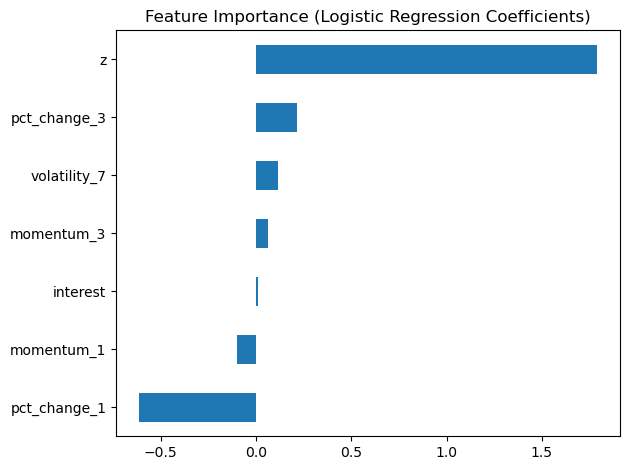

In [15]:
#visualise directional feature influence to support discussion
import matplotlib.pyplot as plt

plt.figure()
coef.plot(kind = "barh")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.tight_layout()
plt.show()

## 10. Operational output (Top-K emerging trends)

### 10.1 Produce "next 3 days emerging trends" table

In [16]:
#operational output: produce a daily Top-K list ranked by predicted emergence probability
#this mimics a real use-case "which keywords should we monitor next?"
#attach predicted probabilities back to rows
out = model_df[["date", "keyword", "interest", "z", "label_emergence"]].copy()
out["pred_prob_emergence_next3d"] = all_probs

#keep only rows where we actually predicted (not NaN)
out = out.dropna(subset = ["pred_prob_emergence_next3d"]).copy()

latest_date = out["date"].max()
latest = (out[out["date"] == latest_date]
    .sort_values("pred_prob_emergence_next3d", ascending = False))

latest.head(10)

,date,keyword,interest,z,label_emergence,pred_prob_emergence_next3d
233,2026-03-01,NamtanFilm,48,-0.080961,0,0.849660
232,2026-03-01,Me and Thee,20,-0.877076,0,0.689764
234,2026-03-01,PondPhuwin,71,0.607771,0,0.594429
230,2026-03-01,GMMTV,37,0.734847,0,0.401084
231,2026-03-01,Girl Rules,38,-1.927795,0,0.043337


In [17]:
#convert probabilities into simple confidence buckets for easier stakeholder interpretation
latest = latest.copy()
latest["rank"] = np.arange(1, len(latest) + 1)

def bucket(p):
    if p >= 0.8: return "Very High"
    if p >= 0.6: return "High"
    if p >= 0.4: return "Medium"
    return "Low"

latest["confidence"] = latest["pred_prob_emergence_next3d"].apply(bucket)
latest.head(10)

,date,keyword,interest,z,label_emergence,pred_prob_emergence_next3d,rank,confidence
233,2026-03-01,NamtanFilm,48,-0.080961,0,0.849660,1,Very High
232,2026-03-01,Me and Thee,20,-0.877076,0,0.689764,2,High
234,2026-03-01,PondPhuwin,71,0.607771,0,0.594429,3,Medium
230,2026-03-01,GMMTV,37,0.734847,0,0.401084,4,Medium
231,2026-03-01,Girl Rules,38,-1.927795,0,0.043337,5,Low


In [18]:
#Top-K hit rate: measures whether at least one true emerging keyword appears in the Top-K predictions per day
#this aligns better with trend discovery than single-row accuracy
def hit_rate_topk(out_df, k = 3):
    #for each date, check if any true emergence is in top-k predicted
    hits = []
    for d, g in out_df.groupby("date"):
        topk = g.sort_values("pred_prob_emergence_next3d", ascending = False).head(k)
        hits.append(int(topk["label_emergence"].max() == 1))
    return float(np.mean(hits)) if len(hits) else np.nan

top3_hit = hit_rate_topk(out, k = 3)
top5_hit = hit_rate_topk(out, k = 5)
top3_hit, top5_hit

(0.8, 0.8285714285714286)

## 11. Visual Sanity Checks

### 11.1 Diagnostic Examples: Interest vs Predicted Emergence Probability

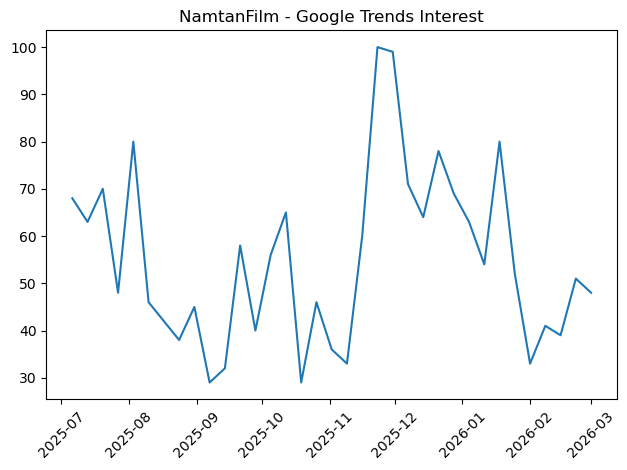

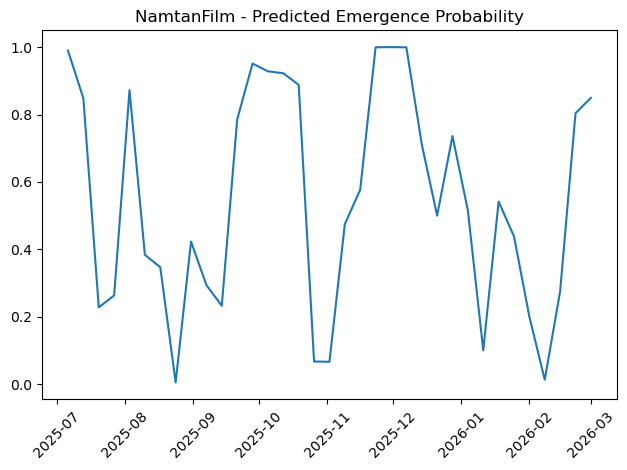

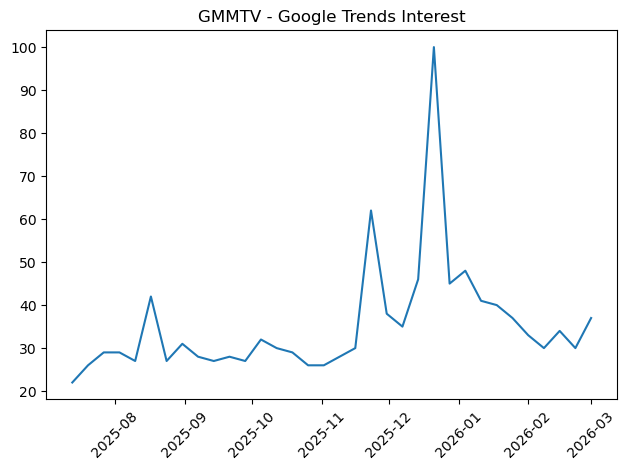

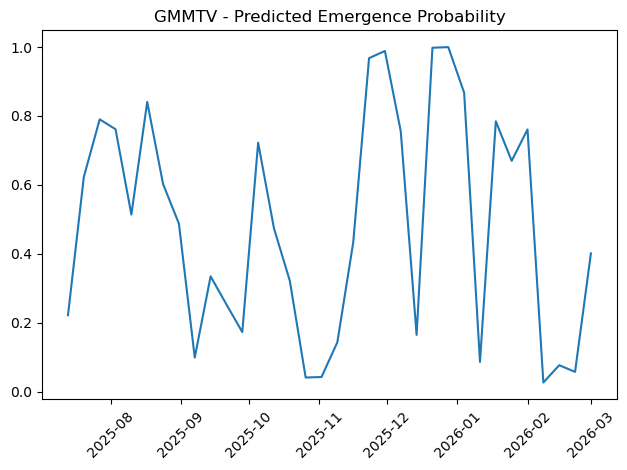

In [19]:
#plot interest to see whether predicted emergence aligns with visible upward movement
def plot_keyword(keyword):
    d = out[out["keyword"] == keyword].sort_values("date")

    #plot google trends interest
    plt.figure()
    plt.plot(d["date"], d["interest"])
    plt.title(f"{keyword} - Google Trends Interest")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

    #plot predicted emergence probability
    if"pred_prob_emergence_next3d" in d.columns:
        plt.figure()
        plt.plot(d["date"], d["pred_prob_emergence_next3d"])
        plt.title(f"{keyword} - Predicted Emergence Probability")
        plt.xticks(rotation = 45)
        plt.tight_layout()
        plt.show()

plot_keyword("NamtanFilm")
plot_keyword("GMMTV")

## 12. Utility

### 12.1 Utility Functions (Reusable Outputs)

In [20]:
#helper function: convenience wrapper to display Top-K emerging keywords for the latest date
def predict_next_h_days(model_df, all_probs, topk = 5):
    out2 = model_df[["date", "keyword", "interest", "z", "label_emergence"]].copy()
    out2["pred_prob_emergence_next3d"] = all_probs
    out2 = out2.dropna(subset = ["pred_prob_emergence_next3d"])

    latest_date = out2["date"].max()
    latest = (out2[out2["date"] == latest_date]
              .sort_values("pred_prob_emergence_next3d", ascending = False)
              .head(topk))
    return latest

predict_next_h_days(model_df, all_probs, topk = 5)

,date,keyword,interest,z,label_emergence,pred_prob_emergence_next3d
233,2026-03-01,NamtanFilm,48,-0.080961,0,0.849660
232,2026-03-01,Me and Thee,20,-0.877076,0,0.689764
234,2026-03-01,PondPhuwin,71,0.607771,0,0.594429
230,2026-03-01,GMMTV,37,0.734847,0,0.401084
231,2026-03-01,Girl Rules,38,-1.927795,0,0.043337


In [21]:
#end-to-end pipeline (demo-ready): packages the core steps into a reusable function to mimic deployment usage
def run_emergence_pipeline(model_df, features, horizon_days = 3, topk = 10):
    X = model_df[features].fillna(0).values
    y = model_df["label_emergence"].values

    clf = LogisticRegression(max_iter = 2000, class_weight = "balanced")
    clf.fit(X, y)
    probs = clf.predict_proba(X)[:, 1]

    out = model_df[["date", "keyword", "interest", "label_emergence"]].copy()
    out["pred_prob_emergence_next3d"] = probs

    latest_date = out["date"].max()
    latest = out[out["date"] == latest_date].sort_values("pred_prob_emergence_next3d", ascending = False).head(topk)
    return latest

run_emergence_pipeline(model_df, FEATURES, horizon_days = HORIZON_DAYS, topk = 10)

,date,keyword,interest,label_emergence,pred_prob_emergence_next3d
233,2026-03-01,NamtanFilm,48,0,0.672023
234,2026-03-01,PondPhuwin,71,0,0.601965
230,2026-03-01,GMMTV,37,0,0.421671
232,2026-03-01,Me and Thee,20,0,0.237424
231,2026-03-01,Girl Rules,38,0,0.015549
